# py50 Quickstart
The following details how to get up and running using py50. These funcitons take in simple parameters to plot the dose-response curves. There are three plotting options - Single Curve, Multi Curve, and Grid Plot. 

In [1]:
import pandas as pd
from py50 import Calculator, PlotCurve

## Calculate Relative and Absolute IC50

In [2]:
# Read in dataset
example = pd.read_csv('../dataset/single_example.csv')

calc_data = Calculator(example)  # Instantiate dataframe into the Calculator class 
calc_data.show()

,Compound Name,Compound Conc,% Inhibition 1,% Inhibition 2,% Inhibition Avg
0,Drug 1,100000.0,90,94,92
1,Drug 1,33300.0,97,89,93
2,Drug 1,11100.0,86,89,88
3,Drug 1,3700.0,81,88,84
4,Drug 1,1240.0,63,70,67


In [3]:
# Perform calculation
# If only relative IC50 needed, can use the calc_data.calculate_ic50() function instead.
calc_data = Calculator(example)
calculation = calc_data.calculate_ic50(name_col='Compound Name', concentration_col='Compound Conc', response_col=['% Inhibition 1', '% Inhibition 2'])
                                                # response_col='% Inhibition Avg')
calculation

,compound_name,maximum,minimum,ic50 (nM),hill_slope
0,Drug 1,92.865625,-8.210081,429.962039,1.024522


## Scale results to pIC50
If IC50 is not your cup of tea, you can quickly scale the values into pIC50 values. This is done using the calculate_pic50() function. It will calculate absolute IC50, but will append two additional columns for hte relative pIC50 and absolute pIC50.

In [4]:
calculation = calc_data.calculate_pic50(name_col='Compound Name', concentration_col='Compound Conc',
                                        response_col='% Inhibition Avg')
calculation

,compound_name,maximum,minimum,relative ic50 (nM),absolute ic50 (nM),hill_slope,relative pIC50,absolute pIC50
0,Drug 1,92.854405,-7.640226,439.824243,584.73401,1.040878,6.356721,6.233042


## Single Curve

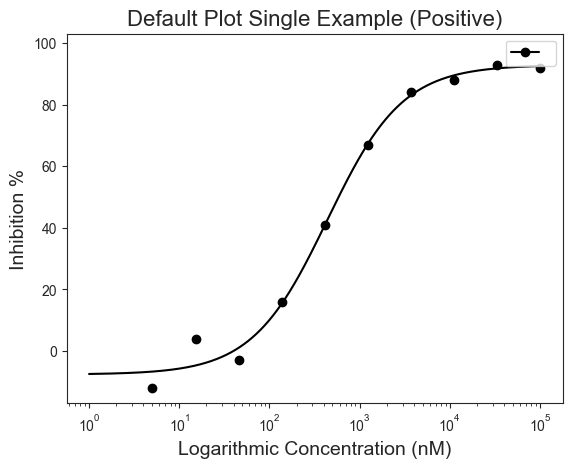

In [5]:
single = pd.read_csv('../dataset/single_example.csv')
plot_data = PlotCurve(single)

figure1 = plot_data.curve_plot(concentration_col='Compound Conc',
                               response_col='% Inhibition Avg',
                               title='Default Plot Single Example (Positive)',
                               name_col='Drug 1',
                               xlabel='Logarithmic Concentration (nM)',
                               ylabel='Inhibition %',
                               legend=True)

In [6]:
plot_data.show()

,Compound Name,Compound Conc,% Inhibition 1,% Inhibition 2,% Inhibition Avg
0,Drug 1,100000.0,90,94,92
1,Drug 1,33300.0,97,89,93
2,Drug 1,11100.0,86,89,88
3,Drug 1,3700.0,81,88,84
4,Drug 1,1240.0,63,70,67


## Multi-Curve

In [7]:
# Read in Dataset
multi = pd.read_csv('../dataset/multiple_example.csv')

# Instantiate dataframe into the PlotCurve class 
plot_data = PlotCurve(multi)

# Optional to inspect table
# plot_data.show()

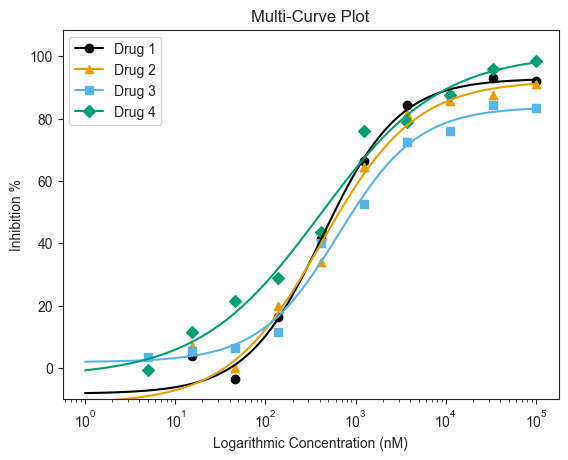

In [8]:
figure3 = plot_data.multi_curve_plot(name_col='Compound Name',
                                     concentration_col='Compound Conc',
                                     response_col='% Inhibition Avg',
                                     title='Multi-Curve Plot',
                                     xlabel='Logarithmic Concentration (nM)',
                                     ylabel='Inhibition %',
                                     legend=True,
                                     ymin=-10,
                                     markersize=10)

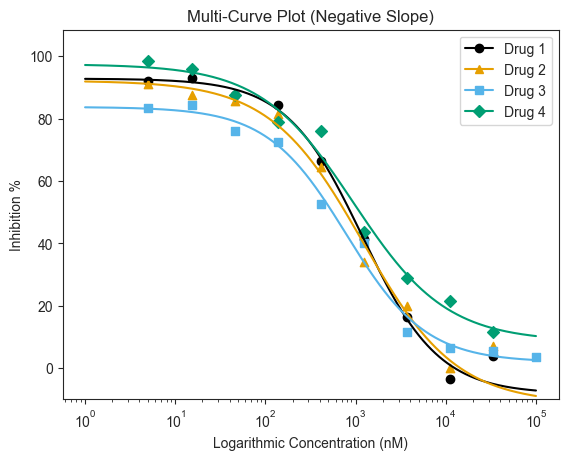

In [9]:
# For negative slope
# Read in Dataset
multi = pd.read_csv('../dataset/multiple_example_negative.csv')

# Instantiate dataframe into the PlotCurve class 
plot_data = PlotCurve(multi)

figure4 = plot_data.multi_curve_plot(name_col='Compound Name',
                                     concentration_col='Compound Conc',
                                     response_col='% Inhibition Avg',
                                     title='Multi-Curve Plot (Negative Slope)',
                                     xlabel='Logarithmic Concentration (nM)',
                                     ylabel='Inhibition %',
                                     legend=True,
                                     ymin=-10)

## Grid Plot

In [10]:
# Read in Dataset
grid = pd.read_csv('../dataset/multiple_example.csv')

# Instantiate dataframe into the PlotCurve class 
grid_plot = PlotCurve(grid)

# Optional to inspect table
grid_plot.show()

,Compound Name,Compound Conc,% Inhibition 1,% Inhibition 2,% Inhibition Avg
0,Drug 1,100000.0,90,94,92.0
1,Drug 1,33300.0,97,89,93.0
2,Drug 1,11100.0,86,89,87.5
3,Drug 1,3700.0,81,88,84.5
4,Drug 1,1240.0,63,70,66.5


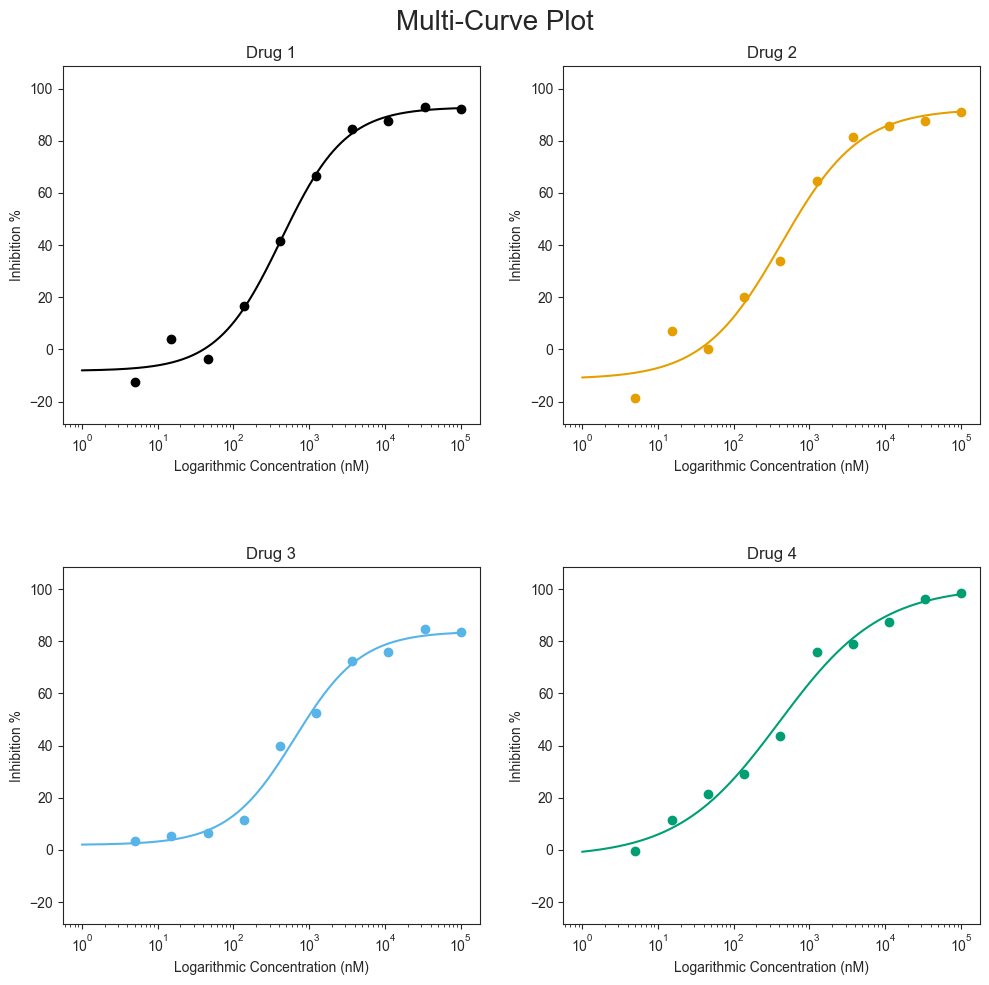

In [11]:
figure5 = grid_plot.grid_curve_plot(name_col='Compound Name',
                                    concentration_col='Compound Conc',
                                    response_col='% Inhibition Avg',
                                    title='Multi-Curve Plot',
                                    xlabel='Logarithmic Concentration (nM)',
                                    ylabel='Inhibition %',
                                    conc_unit='nM',
                                    figsize=(10, 10))